<a href="https://colab.research.google.com/github/abinaya-345/AI-ML-Internship-Projects/blob/main/Bank_Loan_Approval_Prediction_Week_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
# Load Loan Prediction Dataset directly from GitHub
url = "https://raw.githubusercontent.com/Architectshwet/Loan-prediction-using-Machine-Learning-and-Python/master/data/train_u6lujuX_CVtuZ9i.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [7]:
#Display dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 614
Number of columns: 13


In [8]:
#View column names
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [9]:
#Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [10]:
#Statistical summary
df.describe(include="all")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP002990,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


In [11]:
#Check missing values
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [12]:
#Check duplicate records
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [13]:
#Remove duplicate records
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (614, 13)


In [14]:
#Identify categorical columns
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

print("Categorical columns:")
print(categorical_columns.tolist())

Categorical columns:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


In [15]:
#Handle missing values
for column in df.columns:

    if df[column].dtype == "object":
        df[column] = df[column].fillna(
            df[column].mode()[0]
        )
    else:
        df[column] = df[column].fillna(
            df[column].median()
        )

print("Missing values handled successfully!")
print(df.isnull().sum())

Missing values handled successfully!
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [16]:
#Check target column
print(df.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [17]:
#Prepare target variable
target_column = "Loan_Status"

print(df[target_column].value_counts())

Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [18]:
#Encode target variable
label_encoder = LabelEncoder()

df[target_column] = label_encoder.fit_transform(
    df[target_column]
)

print(df[target_column].value_counts())

Loan_Status
1    422
0    192
Name: count, dtype: int64


In [19]:
#Encode categorical features
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(
        df[column]
    )

print("Categorical variables encoded successfully!")
df.head()

Categorical variables encoded successfully!


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [20]:
#Display cleaned dataset
print("Cleaned Dataset:")
display(df.head(10))

Cleaned Dataset:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
5,5,1,1,2,0,1,5417,4196.0,267.0,360.0,1.0,2,1
6,6,1,1,0,1,0,2333,1516.0,95.0,360.0,1.0,2,1
7,7,1,1,3,0,0,3036,2504.0,158.0,360.0,0.0,1,0
8,8,1,1,2,0,0,4006,1526.0,168.0,360.0,1.0,2,1
9,9,1,1,1,0,0,12841,10968.0,349.0,360.0,1.0,1,0


In [21]:
#Separate features and target
X = df.drop(target_column, axis=1)
y = df[target_column]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (614, 12)
Target shape: (614,)


In [22]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 491
Testing samples: 123


In [23]:
#Train Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [24]:
#Make predictions
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:20])

Predictions generated successfully!
[0 1 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 0 0 1]


In [25]:
#Calculate accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8130081300813008
Accuracy (%): 81.30081300813008


In [26]:
#Calculate precision
precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Precision:", precision)

Precision: 0.8089713188798554


In [27]:
#Calculate recall
recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Recall:", recall)

Recall: 0.8130081300813008


In [28]:
#Classification report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.55      0.65        38
           1       0.82      0.93      0.87        85

    accuracy                           0.81       123
   macro avg       0.80      0.74      0.76       123
weighted avg       0.81      0.81      0.80       123



In [29]:
#Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[21 17]
 [ 6 79]]


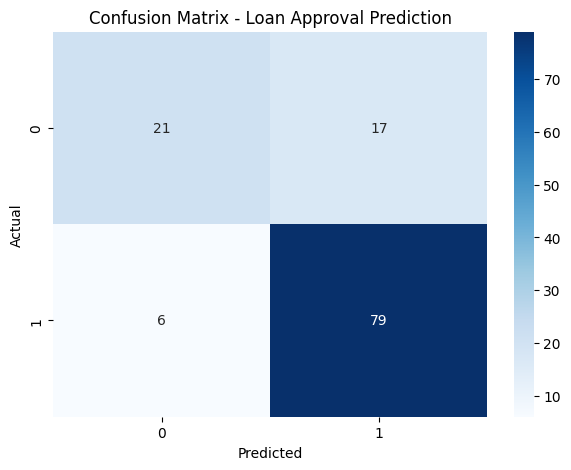

In [30]:
#Confusion Matrix visualization
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Loan Approval Prediction")

plt.show()

In [31]:
#Feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,Credit_History,0.218594
6,ApplicantIncome,0.167046
0,Loan_ID,0.160981
8,LoanAmount,0.154310
7,CoapplicantIncome,0.094049
11,Property_Area,0.047901
3,Dependents,0.043533
9,Loan_Amount_Term,0.041599
2,Married,0.022521
4,Education,0.020146


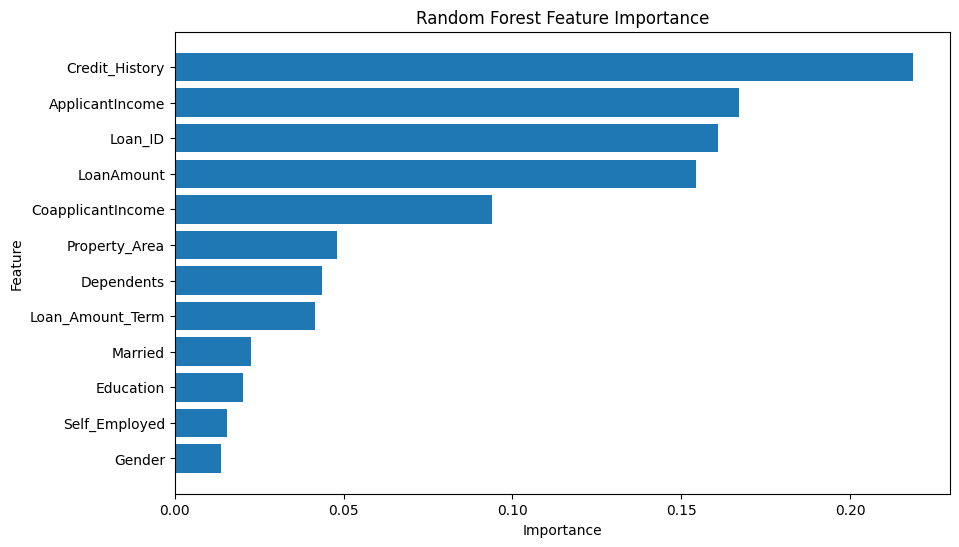

In [32]:
#Feature importance visualization
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [33]:
#Compare actual vs predicted
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,0,0
1,1,1
2,1,1
3,1,1
4,1,1
5,0,1
6,1,1
7,1,1
8,1,0
9,1,1


In [34]:
#Convert predictions to Loan Approved / Not Approved
comparison["Actual_Status"] = comparison["Actual"].map({
    1: "Approved",
    0: "Not Approved"
})

comparison["Predicted_Status"] = comparison["Predicted"].map({
    1: "Approved",
    0: "Not Approved"
})

comparison.head(20)

,Actual,Predicted,Actual_Status,Predicted_Status
0,0,0,Not Approved,Not Approved
1,1,1,Approved,Approved
2,1,1,Approved,Approved
3,1,1,Approved,Approved
4,1,1,Approved,Approved
5,0,1,Not Approved,Approved
6,1,1,Approved,Approved
7,1,1,Approved,Approved
8,1,0,Approved,Not Approved
9,1,1,Approved,Approved


In [35]:
#Create a sample loan prediction
sample = X_test.iloc[[0]]

prediction = model.predict(sample)[0]

if prediction == 1:
    print("Loan Prediction: APPROVED")
else:
    print("Loan Prediction: NOT APPROVED")

Loan Prediction: NOT APPROVED


In [36]:
#Save prediction results
comparison.to_csv(
    "loan_prediction_results.csv",
    index=False
)

print("Prediction results saved successfully!")

Prediction results saved successfully!


In [37]:
#Save cleaned dataset
df.to_csv(
    "cleaned_loan_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [38]:
#Final model summary
print("===================================")
print("BANK LOAN APPROVAL PREDICTION")
print("===================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")

print("===================================")

BANK LOAN APPROVAL PREDICTION
Accuracy  : 0.8130
Precision : 0.8090
Recall    : 0.8130
